In [5]:
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join('../../')))

columns_to_keep = [
    "block_timestamp",
    "transaction_index",
    "fee",
    "total_transferred_value",
    "sent_value",
    "received_value",
    "network_name",
    "avg_sent_value",
    "avg_received_value",
    "sum_sent_value",
    "sum_received_value",
    "sum_total_value_for_sender",
    "sum_total_value_for_receiver",
    "min_sent_value",
    "min_received_value",
    "min_total_value_for_receiver",
    "mode_received_value",
    "stddev_sent_value",
    "stddev_received_value",
    "stddev_total_value_for_receiver",
    "num_sent_transactions",
    "num_received_transactions",
    "avg_time_between_sent_transactions",
    "avg_time_between_received_transactions",
    "avg_outgoing_speed_count",
    "avg_incoming_speed_count",
    "avg_outgoing_speed_value",
    "avg_incoming_speed_value",
    "avg_outgoing_acceleration_count",
    "avg_incoming_acceleration_count",
    "avg_outgoing_acceleration_value",
    "avg_incoming_acceleration_value",
    "avg_fee_paid",
    "total_fee_paid",
    "activity_duration_for_sender",
    "first_transaction_timestamp_for_sender",
    "last_transaction_timestamp_for_sender",
    "activity_duration_for_receiver",
    "first_transaction_timestamp_for_receiver",
    "last_transaction_timestamp_for_receiver",
    "unique_out_degree",
    "unique_in_degree"
]

train_df = pd.read_parquet("../../../data/historical/merged/merged_training_data.parquet")
train_df = train_df[columns_to_keep]
fracToTrain = 300000/len(train_df)
train_df = train_df.sample(frac=fracToTrain, random_state=42)
test_df =  pd.read_parquet("../../../data/benchmark/testing")

In [6]:
X_train = train_df
X_test = test_df[columns_to_keep]
y_test = test_df["label"]
n_neighbors = 20
contamination = 0.0231

lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, novelty=True)
lof.fit(X_train)

LocalOutlierFactor(contamination=0.0231, novelty=True)

In [7]:
outlier_predictions = lof.predict(X_test)
outlier_predictions = pd.Series(outlier_predictions).map({-1: True, 1: False})

c:\Users\wikar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


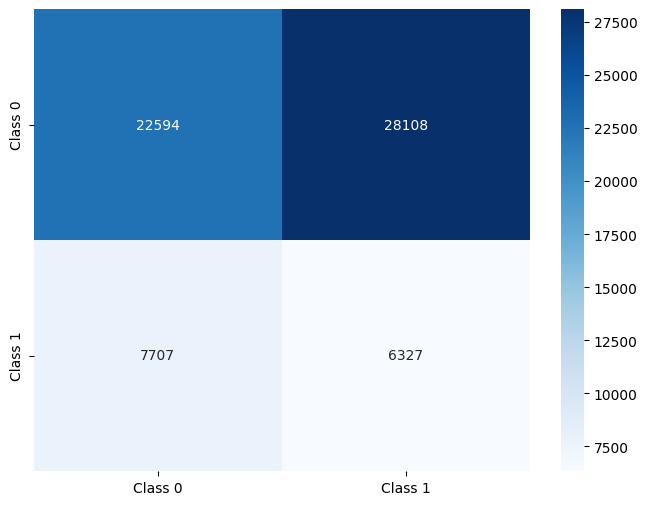

Classification Report:
               precision    recall  f1-score   support

       False       0.75      0.45      0.56     50702
        True       0.18      0.45      0.26     14034

    accuracy                           0.45     64736
   macro avg       0.46      0.45      0.41     64736
weighted avg       0.62      0.45      0.49     64736

Confusion Matrix:
 [[22594 28108]
 [ 7707  6327]]


In [8]:
cm = confusion_matrix(y_test, outlier_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.savefig("../plots/LOF_single.png", dpi=300, bbox_inches="tight")
plt.show()

print("Classification Report:\n", classification_report(y_test, outlier_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, outlier_predictions))